# Imbalance Price – Spread Model

This notebook trains a **log-spread regression** model that predicts the
imbalance price as a function of:

- **Spot price** (EUR/MWh)
- **Imbalance direction** (−1 / 0 / +1)
- **Time-of-day** (sin/cos features in Danish local time)
- **Lag-1 autocorrelation** of the log-absolute spread

The model guarantees:
| Direction | Constraint |
|-----------|------------|
| +1 (up-regulation) | imbalance price ≥ spot price |
|  0 (balanced) | imbalance price = spot price |
| −1 (down-regulation) | imbalance price ≤ spot price |

**Setup:**
- Train on data up to **end of January 2026**; backtest on **February–March 2026**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.scenarios.imbalance_price.spread_model import SpreadModel

## 1. Data Loading

Load 15-min imbalance prices, spot prices and dominating direction from the
Energinet dataset.  Split into train (up to end Jan 2026) and test (Feb–Mar 2026).

Total:   37178 obs  |  2025-03-04 12:00:00 → 2026-03-26 22:45:00
Train:   32000 obs  |  2025-03-04 12:00:00 → 2026-01-31 23:45:00
Test:     5178 obs  |  2026-02-01 00:00:00 → 2026-03-26 22:45:00


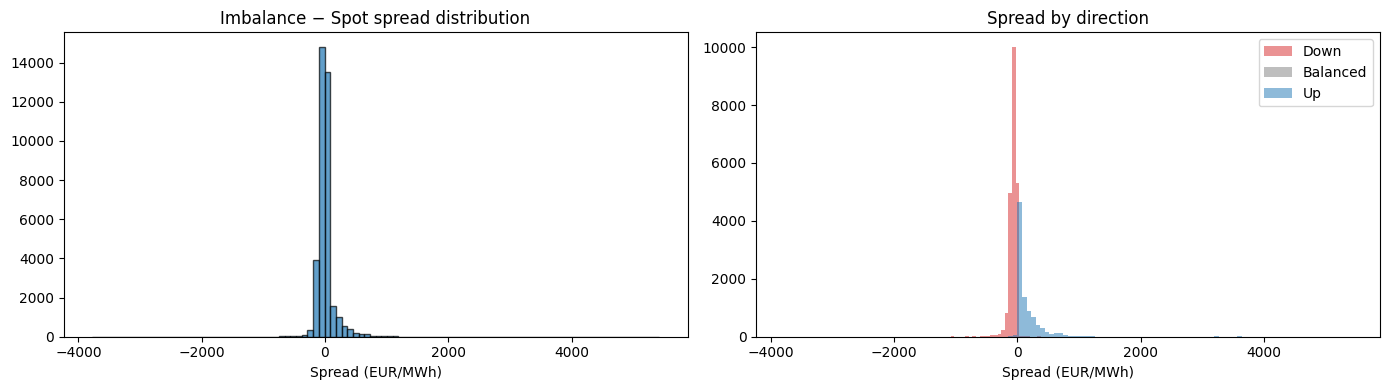

In [2]:
df = pd.read_csv("../data_samples/energinet_imbalance_prices_2024-2026.csv")
df["TimeUTC"] = pd.to_datetime(df["TimeUTC"])
df = df.set_index("TimeUTC").sort_index()

# Drop rows with missing values in the key columns
df = df.dropna(subset=["ImbalancePriceEUR", "SpotPriceEUR", "DominatingDirection"])

# Train / test split
train = df[df.index < "2026-02-01"]
test = df[df.index >= "2026-02-01"]

print(f"Total:  {len(df):>6} obs  |  {df.index[0]} → {df.index[-1]}")
print(f"Train:  {len(train):>6} obs  |  {train.index[0]} → {train.index[-1]}")
print(f"Test:   {len(test):>6} obs  |  {test.index[0]} → {test.index[-1]}")

# Quick look at the spread distribution
spread = df["ImbalancePriceEUR"] - df["SpotPriceEUR"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(spread, bins=100, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Spread (EUR/MWh)")
axes[0].set_title("Imbalance − Spot spread distribution")

for d, label, color in [(-1, "Down", "tab:red"), (0, "Balanced", "tab:gray"), (1, "Up", "tab:blue")]:
    mask = df["DominatingDirection"] == d
    axes[1].hist(spread[mask], bins=80, alpha=0.5, label=label, color=color)
axes[1].set_xlabel("Spread (EUR/MWh)")
axes[1].set_title("Spread by direction")
axes[1].legend()

plt.tight_layout()

## 2. Model Fitting

Fit the `SpreadModel` on the training set. The model targets
`log(|spread| + 1)` for observations where direction ≠ 0, with features:
intercept, spot price, direction, sin/cos time-of-day, and lag-1 of the
log-absolute spread.

In [3]:
model = SpreadModel()
model.fit(
    imbalance_prices=train["ImbalancePriceEUR"].values,
    spot_prices=train["SpotPriceEUR"].values,
    directions=train["DominatingDirection"].values,
    timestamps_utc=pd.DatetimeIndex(train.index),
)

feature_names = ["intercept", "spot_price", "direction", "sin_tod", "cos_tod", "lag1_log_spread"]
print("Fitted coefficients:")
for name, coef in zip(feature_names, model.coefficients):
    print(f"  {name:20s} = {coef:+.6f}")
print(f"\nResidual std:    {model.residual_std:.4f}")
print(f"Log-spread cap:  {model.log_spread_cap:.4f}  (max abs spread ≈ {np.exp(model.log_spread_cap) - 1:.0f} EUR/MWh)")

Fitted coefficients:
  intercept            = +2.227100
  spot_price           = +0.005612
  direction            = -0.077447
  sin_tod              = +0.011907
  cos_tod              = +0.097159
  lag1_log_spread      = +0.307164

Residual std:    1.4948
Log-spread cap:  8.1810  (max abs spread ≈ 3571 EUR/MWh)


## 3. Save Model

In [4]:
from pathlib import Path

save_dir = Path("../trained_models/imbalance_price")
save_dir.mkdir(parents=True, exist_ok=True)
model.save(save_dir / "spread.npz")
print(f"Saved to {save_dir / 'spread.npz'}")

Saved to ../trained_models/imbalance_price/spread.npz


## 4. Backtest (Feb–Mar 2026)

For each day in the test set, generate 500 imbalance price scenarios
conditioned on the **actual** spot prices and **actual** directions for
that day, then compare against the realised imbalance prices.

This isolates the spread-model quality from the spot/direction model errors.

In [5]:
from src.scenarios.base import N_STEPS

n_scenarios = 500
test_days = sorted(test.index.normalize().unique())

results = []

for day in test_days:
    day_str = day.strftime("%Y-%m-%d")
    day_data = df.loc[day_str]
    if len(day_data) < N_STEPS:
        continue

    actual_imb = day_data["ImbalancePriceEUR"].values[:N_STEPS]
    actual_spot = day_data["SpotPriceEUR"].values[:N_STEPS]
    actual_dir = day_data["DominatingDirection"].values[:N_STEPS]

    # Last observed spread before the delivery day
    prev_data = df.loc[:day - pd.Timedelta("15min")]
    last_spread = float(
        prev_data["ImbalancePriceEUR"].iloc[-1] - prev_data["SpotPriceEUR"].iloc[-1]
    )

    # Use actual spot & direction as inputs (perfect-foresight backtest)
    spot_tiled = np.tile(actual_spot, (n_scenarios, 1))
    dir_tiled = np.tile(actual_dir, (n_scenarios, 1))

    scenarios = model.generate(
        n_scenarios=n_scenarios,
        seed=42,
        spot_price=spot_tiled,
        imbalance_direction=dir_tiled,
        last_spread=last_spread,
        delivery_date=day_str,
    )

    median_scenario = np.median(scenarios, axis=0)
    mae = np.mean(np.abs(median_scenario - actual_imb))

    # 90% coverage: fraction of actual values inside [5th, 95th] percentile
    lo = np.percentile(scenarios, 5, axis=0)
    hi = np.percentile(scenarios, 95, axis=0)
    coverage = np.mean((actual_imb >= lo) & (actual_imb <= hi))

    # Direction constraint check
    for s in range(n_scenarios):
        for t in range(N_STEPS):
            d = dir_tiled[s, t]
            if d == 1:
                assert scenarios[s, t] >= spot_tiled[s, t] - 1e-9, \
                    f"Constraint violated: up-reg scenario < spot on {day_str} step {t}"
            elif d == -1:
                assert scenarios[s, t] <= spot_tiled[s, t] + 1e-9, \
                    f"Constraint violated: down-reg scenario > spot on {day_str} step {t}"
            elif d == 0:
                assert abs(scenarios[s, t] - spot_tiled[s, t]) < 1e-9, \
                    f"Constraint violated: balanced scenario ≠ spot on {day_str} step {t}"

    results.append({"date": day_str, "mae": mae, "coverage_90": coverage})

results_df = pd.DataFrame(results)
print(f"Backtest: {len(results_df)} days")
print(f"  Mean MAE:          {results_df['mae'].mean():.2f} EUR/MWh")
print(f"  Median MAE:        {results_df['mae'].median():.2f} EUR/MWh")
print(f"  Mean 90% coverage: {results_df['coverage_90'].mean():.1%}")
print(f"\n✓ All direction constraints satisfied across {n_scenarios}×{len(results_df)} scenario-days.")

Backtest: 52 days
  Mean MAE:          46.65 EUR/MWh
  Median MAE:        36.64 EUR/MWh
  Mean 90% coverage: 90.3%

✓ All direction constraints satisfied across 500×52 scenario-days.


## 5. Example Fan Chart

Plot a single-day backtest: scenario fan (5th–95th percentile), median,
and the actual imbalance price.

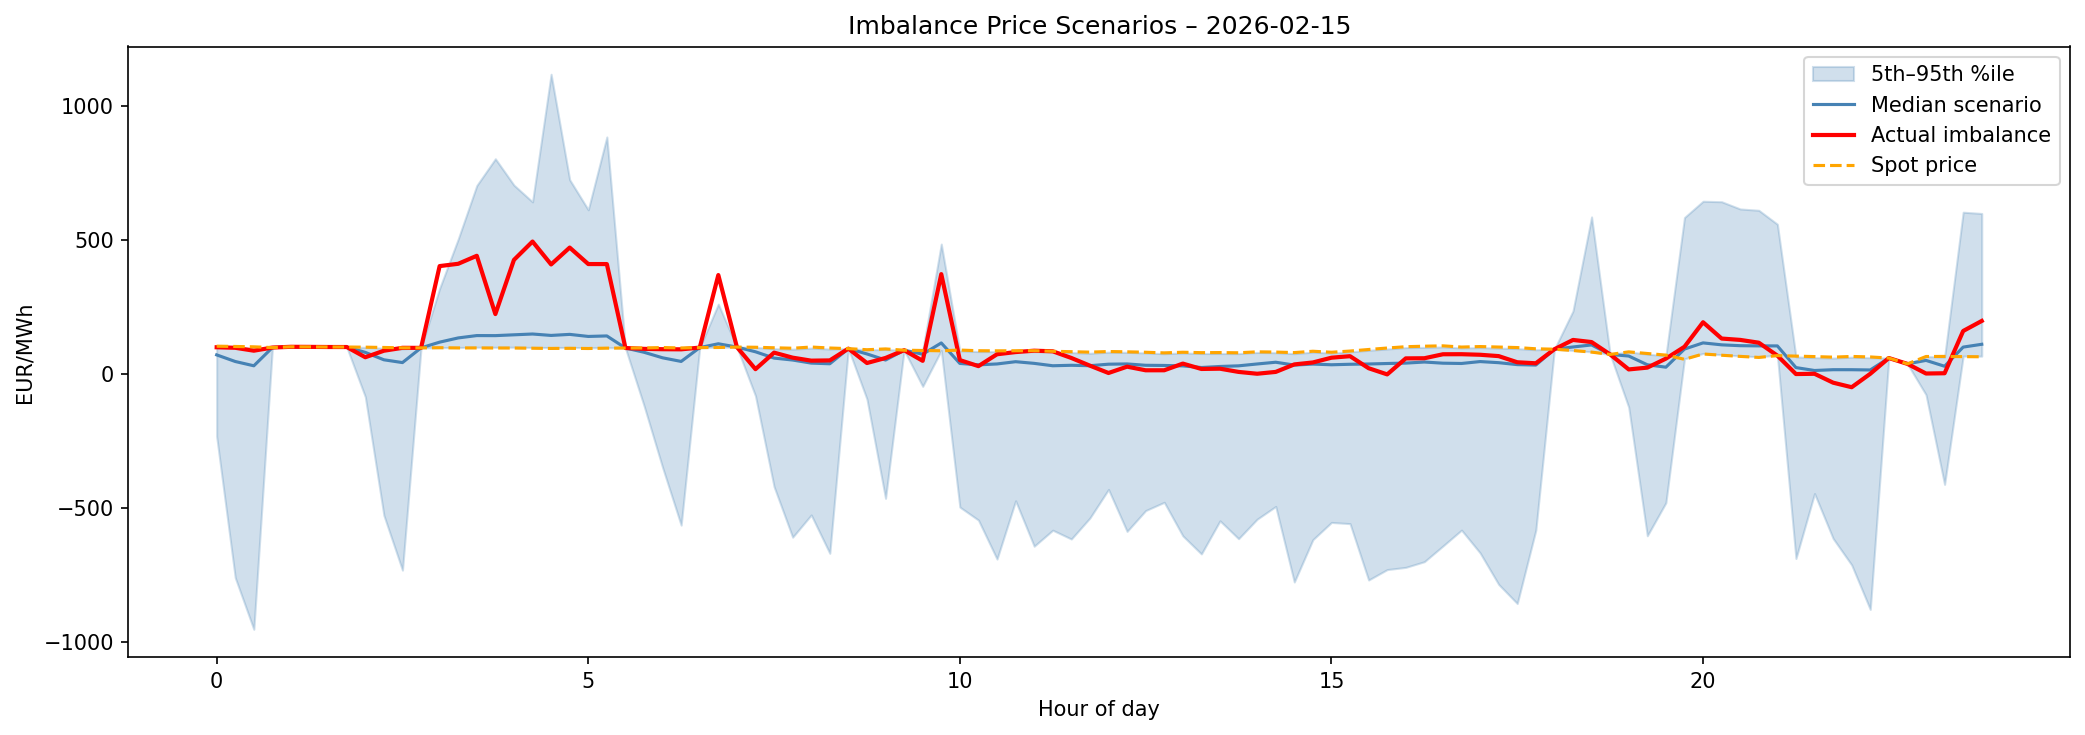

In [6]:
example_day = "2026-02-15"
day_data = df.loc[example_day]
actual_imb = day_data["ImbalancePriceEUR"].values[:N_STEPS]
actual_spot = day_data["SpotPriceEUR"].values[:N_STEPS]
actual_dir = day_data["DominatingDirection"].values[:N_STEPS]

prev_data = df.loc[:pd.Timestamp(example_day) - pd.Timedelta("15min")]
last_spread = float(prev_data["ImbalancePriceEUR"].iloc[-1] - prev_data["SpotPriceEUR"].iloc[-1])

spot_tiled = np.tile(actual_spot, (n_scenarios, 1))
dir_tiled = np.tile(actual_dir, (n_scenarios, 1))

scenarios = model.generate(
    n_scenarios=n_scenarios, seed=123,
    spot_price=spot_tiled, imbalance_direction=dir_tiled,
    last_spread=last_spread, delivery_date=example_day,
)

hours = np.arange(N_STEPS) * 0.25
lo5 = np.percentile(scenarios, 5, axis=0)
hi95 = np.percentile(scenarios, 95, axis=0)
med = np.median(scenarios, axis=0)

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
ax.fill_between(hours, lo5, hi95, alpha=0.25, color="steelblue", label="5th–95th %ile")
ax.plot(hours, med, color="steelblue", lw=1.5, label="Median scenario")
ax.plot(hours, actual_imb, color="red", lw=2, label="Actual imbalance")
ax.plot(hours, actual_spot, color="orange", lw=1.5, ls="--", label="Spot price")
ax.set_xlabel("Hour of day")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Imbalance Price Scenarios – {example_day}")
ax.legend()
plt.tight_layout()